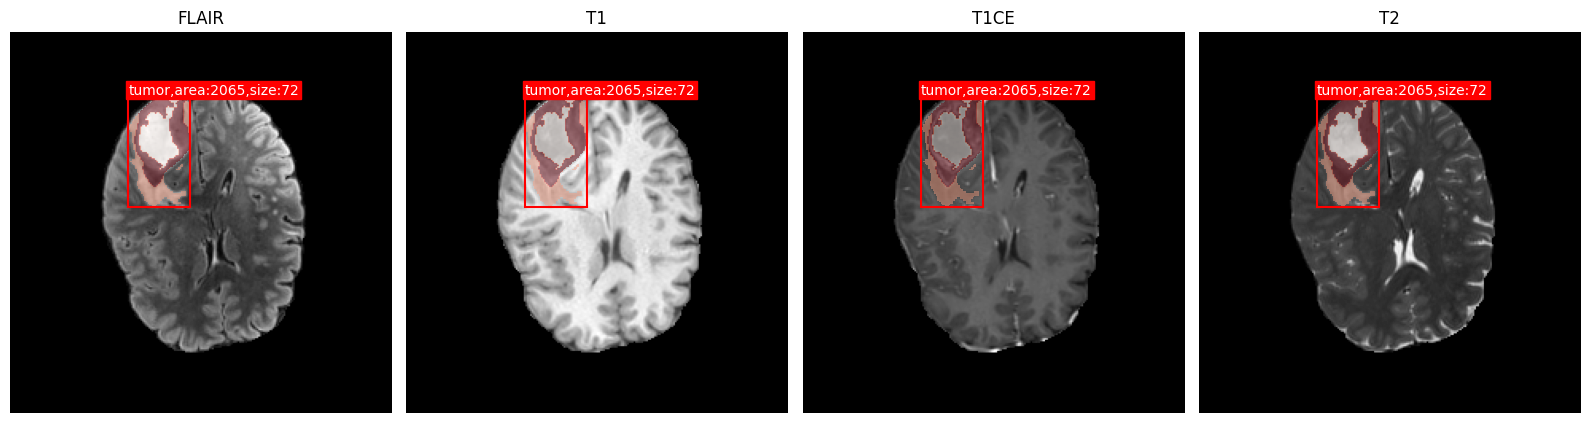

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nb
import matplotlib.patches as patches

base_path = "BraTS2021_00495"

modalities = {
    "FLAIR": f"{base_path}/BraTS2021_00495_flair.nii.gz",
    "T1":    f"{base_path}/BraTS2021_00495_t1.nii.gz",
    "T1CE":  f"{base_path}/BraTS2021_00495_t1ce.nii.gz",
    "T2":    f"{base_path}/BraTS2021_00495_t2.nii.gz",
}

seg_path = f"{base_path}/BraTS2021_00495_seg.nii.gz"

# load segmentation
seg = nb.load(seg_path).get_fdata()

# choose slice with largest tumor
sums = seg.sum(axis=(0, 1))
z = int(np.argmax(sums)) if sums.max() > 0 else seg.shape[2] // 2

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (name, path) in zip(axes, modalities.items()):
    img = nb.load(path).get_fdata()
    slice_img = np.rot90(img[:, :, z])
    slice_seg = np.rot90(seg[:, :, z])

    ax.imshow(slice_img, cmap="gray")

    ax.imshow(
        np.ma.masked_where(slice_seg == 0, slice_seg),
        cmap="Reds",
        alpha=0.45
    )

    ys, xs = np.where(slice_seg > 0)
    if len(xs) > 0:
        x_min, x_max = xs.min(), xs.max()
        y_min, y_max = ys.min(), ys.max()

        # compute stats
        tumor_area = len(xs)
        tumor_size = max(x_max - x_min, y_max - y_min)

        # draw bounding box
        rect = patches.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=1.5,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

        # label exactly like header on the box
        label = f"tumor,area:{tumor_area},size:{tumor_size}"

        ax.text(
            x_min,
            y_min - 6,           # small offset above box
            label,
            color="white",
            fontsize=10,
            verticalalignment="top",
            bbox=dict(
                facecolor="red",
                edgecolor="red",
                pad=1.5
            )
        )

    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()
